In [77]:
import QUANTAXIS as QA
from QAStrategy.qastockbase import QAStrategyStockBase
import numpy as np

class CCI(QAStrategyStockBase):
    def on_bar(self, bar):
        current_code = bar.name[1]
        

        res = self.cci(current_code)
#         print(res.CCI[-1])
        print(res)
        print(self.acc.cash_available)
        
        
#         if res.CCI[-1] < -100:
        if res > 5:
            print('LONG',current_code,self.get_positions(current_code).volume_long)
#             if self.get_positions(current_code).volume_long == 0:
            self.send_order('BUY', 'OPEN', price=bar['close'], volume=10000, code= current_code)

        else:
            print('SHORT',current_code,self.get_positions(current_code).volume_long)
            if self.get_positions(current_code).volume_long > 0:
                self.send_order('SELL', 'CLOSE', price=bar['close'], volume=10000, code= current_code)

    def cci(self, code):
#         market_data = self.get_code_marketdata(code)
#         return QA.QA_indicator_CCI(self.market_data, 10)
        return np.random.randint(0,9)
        
        

In [79]:
%%time
s = CCI(code=['000001', '000002'], frequence='day', start='2019-08-01', end='2019-10-01', strategy_id='x')
s.debug()

 prortfolio with user_cookie  USER_u8pObTlF  already exist!!
QAACCPRO: reload from DATABASE
{}
< QA_AccountPRO x market: stock_cn>
stock_cn
backtest: Settle!
4
1000000
SHORT 000001 0
6
1000000
LONG 000002 0
backtest: Settle!
7
715728.95
LONG 000001 0
3
578294.6
SHORT 000002 10000
backtest: Settle!
8
858044.475
LONG 000001 10000
7
724511.1
LONG 000002 0
backtest: Settle!
7
454343.57499999995
LONG 000001 20000
8
320610.14999999997
LONG 000002 10000
backtest: Settle!
6
50342.59999999996
LONG 000001 30000
ALERT MONEY NOT ENOUGH!!!
50342.59999999996
6
50342.59999999996
LONG 000002 20000
ALERT MONEY NOT ENOUGH!!!
50342.59999999996
backtest: Settle!
5
50342.59999999996
SHORT 000001 30000
8
193962.84999999998
LONG 000002 20000
ALERT MONEY NOT ENOUGH!!!
193962.84999999998
backtest: Settle!
6
193962.84999999998
LONG 000001 20000
5
48726.549999999974
SHORT 000002 20000
backtest: Settle!
3
321285.425
SHORT 000001 30000
7
472296.425
LONG 000002 10000
backtest: Settle!
5
194527.0
SHORT 000001 20000


In [51]:
s.acc.history_table

,datetime,code,price,amount,cash,order_id,realorder_id,trade_id,account_cookie,commission,tax,message,frozen,direction,total_frozen
0,2019-08-01 00:00:00,000002,28.42,10000,715728.950,2ad7f360-4f7e-4db0-9404-c07329de8a2d,None,None,x,71.050,0.0,None,0,1,0
1,2019-08-02 00:00:00,000002,28.01,-10000,995478.825,86ffcd0c-e45f-47ae-bc19-6aa1efa470d4,None,None,x,70.025,280.1,None,0,-1,0
2,2019-08-05 00:00:00,000001,13.35,10000,861945.450,e41b5aba-648d-407d-af88-b042639ad5e0,None,None,x,33.375,0.0,None,0,1,0
3,2019-08-06 00:00:00,000001,13.37,-10000,995478.325,85f51135-1c2e-4beb-b44e-7505bfcaf5ec,None,None,x,33.425,133.7,None,0,-1,0
4,2019-08-06 00:00:00,000002,27.02,10000,725210.775,9244144c-24ba-41d8-a1de-7f5f19cfbbb2,None,None,x,67.550,0.0,None,0,1,0
5,2019-08-07 00:00:00,000002,27.36,-10000,998468.775,2f41cbfe-842f-457d-a02f-0c49f3061493,None,None,x,68.400,273.6,None,0,-1,0
6,2019-08-09 00:00:00,000001,14.52,10000,853232.475,3fb4eb7c-56e1-4cf3-9954-b56d3fbf9792,None,None,x,36.300,0.0,None,0,1,0
7,2019-08-09 00:00:00,000002,27.29,10000,580264.250,24f96017-b421-4d07-b521-08a7d3f2b163,None,None,x,68.225,0.0,None,0,1,0
8,2019-08-12 00:00:00,000001,15.12,-10000,731275.250,0845fd81-a53b-4528-81f4-555d4b87bea5,None,None,x,37.800,151.2,None,0,-1,0
9,2019-08-12 00:00:00,000002,27.77,-10000,1008628.125,ff0f29e0-f373-42a5-890e-c160e10bba2f,None,None,x,69.425,277.7,None,0,-1,0


In [70]:
s.get_positions('000002').static_message

{'code': '000002',
 'instrument_id': '000002',
 'user_id': 'x',
 'portfolio_cookie': 'default',
 'username': 'quantaxis',
 'position_id': '37a38756-fee2-4b56-8184-46f20b7c39a5',
 'account_cookie': 'x',
 'frozen': {},
 'name': None,
 'spms_id': None,
 'oms_id': None,
 'market_type': 'stock_cn',
 'exchange_id': None,
 'moneypreset': 100000,
 'moneypresetLeft': 65699.99999999994,
 'lastupdatetime': '',
 'volume_long_today': 0,
 'volume_long_his': 0,
 'volume_long': 0,
 'volume_short_today': 0,
 'volume_short_his': 0,
 'volume_short': 0,
 'volume_long_frozen_today': 0,
 'volume_long_frozen_his': 0,
 'volume_long_frozen': 0,
 'volume_short_frozen_today': 0,
 'volume_short_frozen_his': 0,
 'volume_short_frozen': 0,
 'margin_long': -1.1641532182693481e-10,
 'margin_short': 0,
 'margin': -1.1641532182693481e-10,
 'position_price_long': 26.765,
 'position_cost_long': 0.0,
 'position_price_short': 0,
 'position_cost_short': 0.0,
 'open_price_long': 26.765,
 'open_cost_long': 0.0,
 'open_price_sh

[]

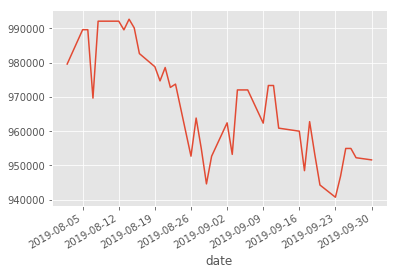

In [71]:
Risk = QA.QA_Risk(s.acc)
fig = Risk.assets.plot()
fig.plot()

[]

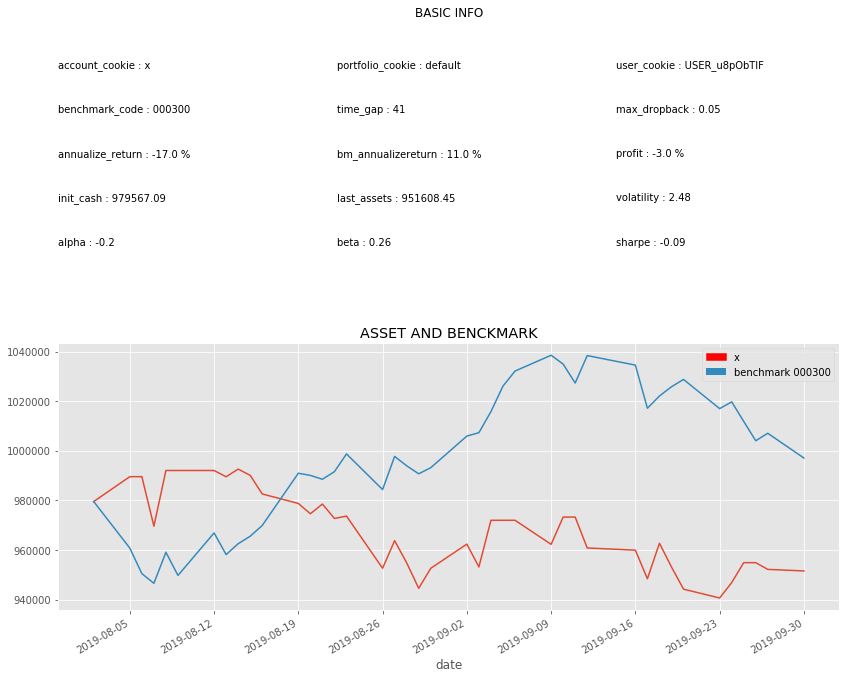

In [80]:
fig = Risk.plot_assets_curve()
fig.plot()

{'total_profit': 29400.0,
 'total_loss': -70600.0,
 'total_pnl': 0.42,
 'trading_amounts': 22,
 'profit_amounts': 8,
 'loss_amounts': 14,
 'even_amounts': 0,
 'profit_precentage': 0.36,
 'loss_precentage': 0.64,
 'even_precentage': 0.0,
 'average_profit': 3675.0,
 'average_loss': -5042.86,
 'average_pnl': 0.73,
 'max_profit': 10000.0,
 'max_loss': -12000.0,
 'max_pnl': 0.83,
 'netprofio_maxloss_ratio': 3.43,
 'continue_profit_amount': 2,
 'continue_loss_amount': 3,
 'average_holdgap': '3 days 04:21:49.090909090',
 'average_profitholdgap': '1 days 18:00:00',
 'average_losssholdgap': '4 days 00:00:00',
 'buyopen': {'total_profit': 29400.0,
  'total_loss': -70600.0,
  'total_pnl': 0.42,
  'trading_amounts': 22,
  'profit_amounts': 8,
  'loss_amounts': 14,
  'even_amounts': 0,
  'profit_precentage': 0.36,
  'loss_precentage': 0.64,
  'even_precentage': 0.0,
  'average_profit': 3675.0,
  'average_loss': -5042.86,
  'average_pnl': 0.73,
  'max_profit': 10000.0,
  'max_loss': -12000.0,
  'max

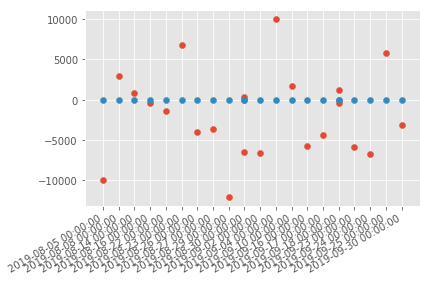

In [72]:
pr=QA.QA_Performance(s.acc)
pr.pnl_fifo
pr.plot_pnlmoney()
pr.plot_pnlratio()
pr.message